# Final Project: Analyzing the Impact of Recession on Automobile Sales
### XYZAutomotives — Data Science Analysis
---

## Setup: Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (528, 15)

Columns: ['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


---
## Part 1: Visualizations using Matplotlib & Seaborn
---

### TASK 1.1: Line Chart — Automobile Sales Fluctuation Year to Year

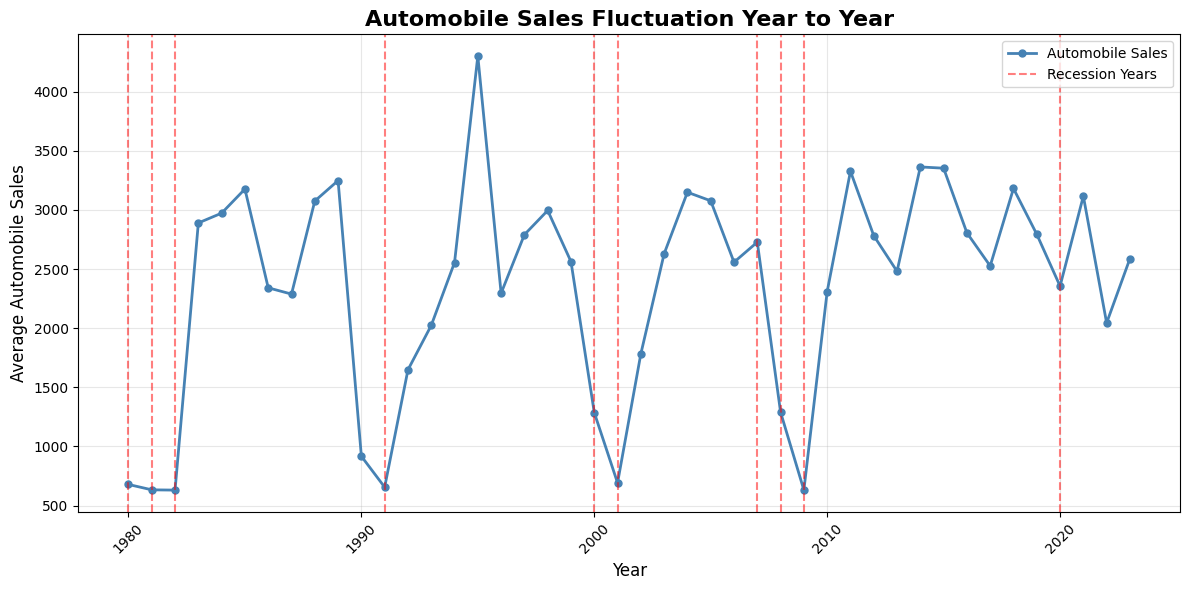

✅ Task 1.1 Done


In [2]:
# Group by Year and calculate mean automobile sales
df_line = df.groupby('Year')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_line['Year'], df_line['Automobile_Sales'],
         color='steelblue', linewidth=2, marker='o', markersize=5)

# Highlight recession years
recession_years = [1980, 1981, 1982, 1991, 2000, 2001, 2007, 2008, 2009, 2020]
for yr in recession_years:
    if yr in df_line['Year'].values:
        plt.axvline(x=yr, color='red', linestyle='--', alpha=0.5)

plt.title('Automobile Sales Fluctuation Year to Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Automobile Sales', fontsize=12)
plt.legend(['Automobile Sales', 'Recession Years'], fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_1_line_chart.png', dpi=150)
plt.show()
print('✅ Task 1.1 Done')

### TASK 1.2: Advertising Expenditure vs Automobile Sales (Non-Recession)

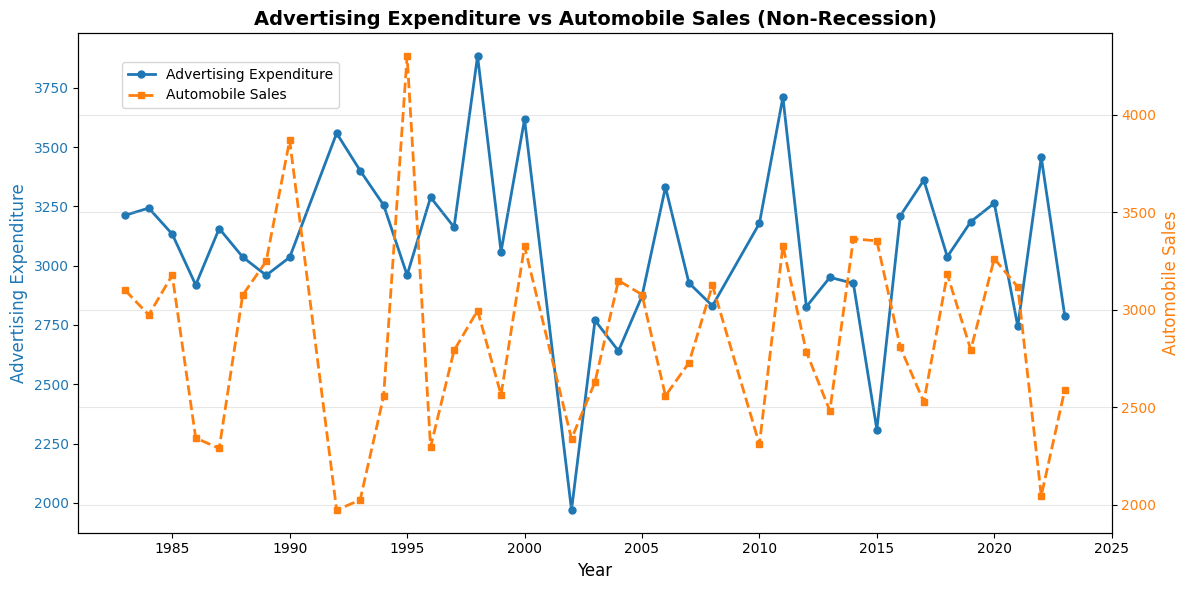

✅ Task 1.2 Done


In [3]:
# Filter non-recession data
df_non_rec = df[df['Recession'] == 0]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Advertising expenditure
color1 = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Advertising Expenditure', color=color1, fontsize=12)
ax1.plot(df_non_rec.groupby('Year')['Advertising_Expenditure'].mean(),
         color=color1, linewidth=2, marker='o', markersize=5)
ax1.tick_params(axis='y', labelcolor=color1)

# Automobile sales
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Automobile Sales', color=color2, fontsize=12)
ax2.plot(df_non_rec.groupby('Year')['Automobile_Sales'].mean(),
         color=color2, linewidth=2, marker='s', markersize=5, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Advertising Expenditure vs Automobile Sales (Non-Recession)', fontsize=14, fontweight='bold')
fig.legend(['Advertising Expenditure', 'Automobile Sales'], loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_2_adv_vs_sales.png', dpi=150)
plt.show()
print('✅ Task 1.2 Done')

### TASK 1.3: Seaborn — Sales Trend per Vehicle Type (Recession vs Non-Recession)

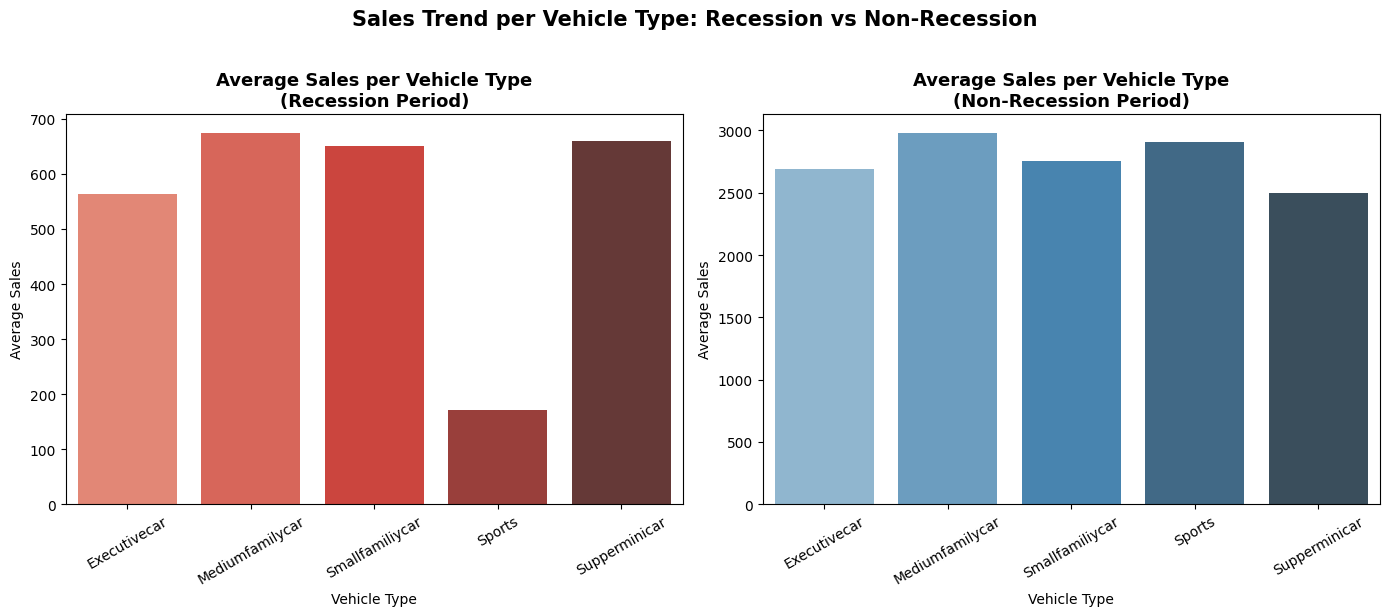

✅ Task 1.3 Done


In [4]:
# Prepare data
df_rec    = df[df['Recession'] == 1]
df_non_rec = df[df['Recession'] == 0]

sales_rec     = df_rec.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()
sales_non_rec = df_non_rec.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=sales_rec, x='Vehicle_Type', y='Automobile_Sales',
            palette='Reds_d', ax=axes[0])
axes[0].set_title('Average Sales per Vehicle Type\n(Recession Period)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Vehicle Type')
axes[0].set_ylabel('Average Sales')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=sales_non_rec, x='Vehicle_Type', y='Automobile_Sales',
            palette='Blues_d', ax=axes[1])
axes[1].set_title('Average Sales per Vehicle Type\n(Non-Recession Period)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Average Sales')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Sales Trend per Vehicle Type: Recession vs Non-Recession', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task1_3_vehicle_type_seaborn.png', dpi=150)
plt.show()
print('✅ Task 1.3 Done')

### TASK 1.4: Subplots — GDP Variations During Recession vs Non-Recession

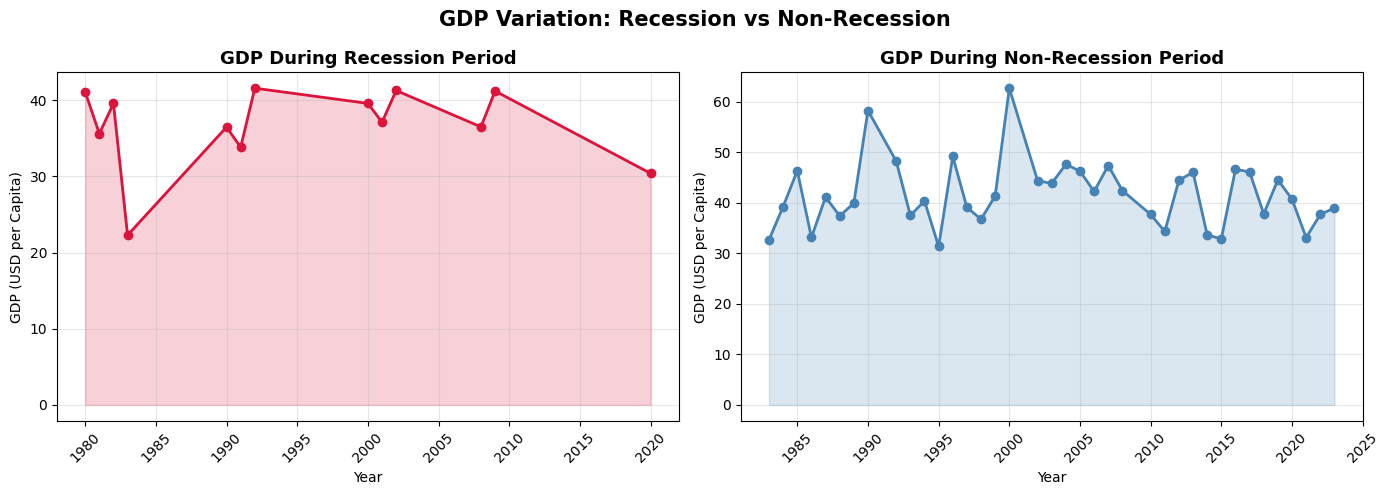

✅ Task 1.4 Done


In [5]:
df_rec     = df[df['Recession'] == 1]
df_non_rec = df[df['Recession'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recession GDP
gdp_rec = df_rec.groupby('Year')['GDP'].mean()
axes[0].plot(gdp_rec.index, gdp_rec.values,
             color='crimson', linewidth=2, marker='o', markersize=6)
axes[0].set_title('GDP During Recession Period', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP (USD per Capita)')
axes[0].fill_between(gdp_rec.index, gdp_rec.values, alpha=0.2, color='crimson')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Non-Recession GDP
gdp_non_rec = df_non_rec.groupby('Year')['GDP'].mean()
axes[1].plot(gdp_non_rec.index, gdp_non_rec.values,
             color='steelblue', linewidth=2, marker='o', markersize=6)
axes[1].set_title('GDP During Non-Recession Period', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP (USD per Capita)')
axes[1].fill_between(gdp_non_rec.index, gdp_non_rec.values, alpha=0.2, color='steelblue')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('GDP Variation: Recession vs Non-Recession', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_4_gdp_subplots.png', dpi=150)
plt.show()
print('✅ Task 1.4 Done')

### TASK 1.5: Bubble Plot — Impact of Seasonality on Automobile Sales

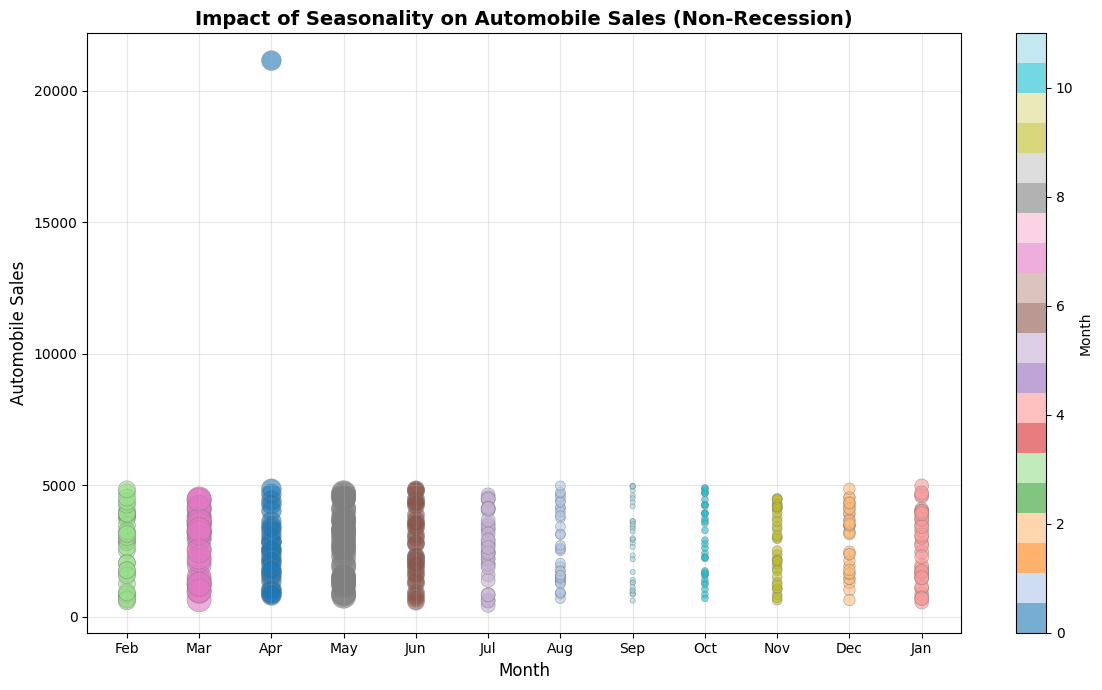

✅ Task 1.5 Done


In [6]:
df_non_rec = df[df['Recession'] == 0]

# Bubble size = Seasonality_Weight
size = df_non_rec['Seasonality_Weight'] * 200
colors = df_non_rec['Month'].astype('category').cat.codes

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_non_rec['Month'],
    df_non_rec['Automobile_Sales'],
    s=size,
    c=colors,
    cmap='tab20',
    alpha=0.6,
    edgecolors='grey',
    linewidth=0.5
)

plt.title('Impact of Seasonality on Automobile Sales (Non-Recession)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.colorbar(scatter, label='Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_5_bubble_plot.png', dpi=150)
plt.show()
print('✅ Task 1.5 Done')

### TASK 1.6: Scatter Plot — Vehicle Price vs Sales Volume During Recession

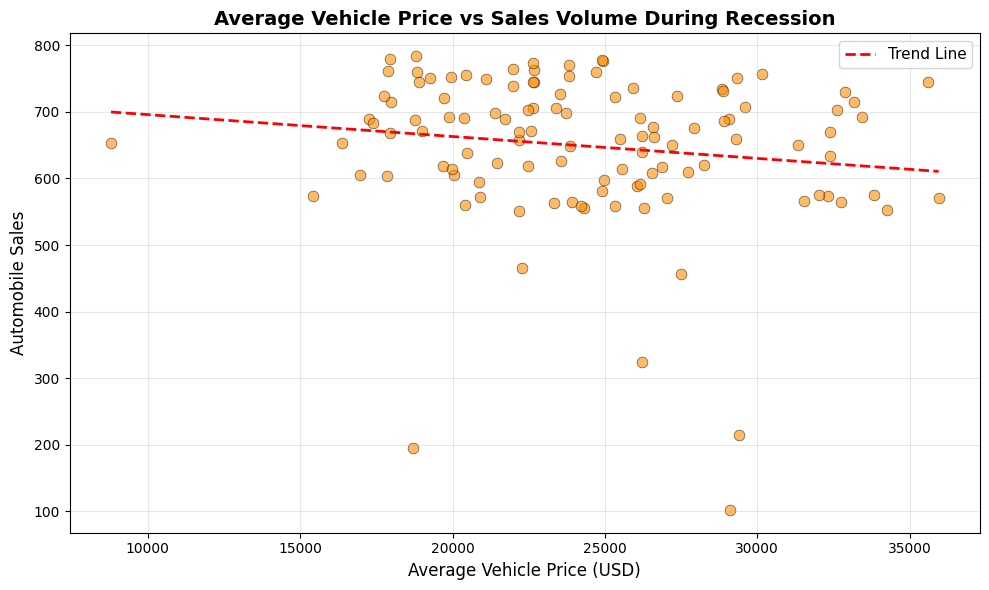

✅ Task 1.6 Done


In [7]:
df_rec = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
plt.scatter(
    df_rec['Price'],
    df_rec['Automobile_Sales'],
    color='darkorange',
    alpha=0.6,
    edgecolors='black',
    linewidths=0.5,
    s=60
)

# Trend line
z = np.polyfit(df_rec['Price'], df_rec['Automobile_Sales'], 1)
p = np.poly1d(z)
sorted_price = np.sort(df_rec['Price'])
plt.plot(sorted_price, p(sorted_price), 'r--', linewidth=2, label='Trend Line')

plt.title('Average Vehicle Price vs Sales Volume During Recession', fontsize=14, fontweight='bold')
plt.xlabel('Average Vehicle Price (USD)', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_6_scatter_price_sales.png', dpi=150)
plt.show()
print('✅ Task 1.6 Done')

### TASK 1.7: Pie Chart — Advertising Expenditure During Recession vs Non-Recession

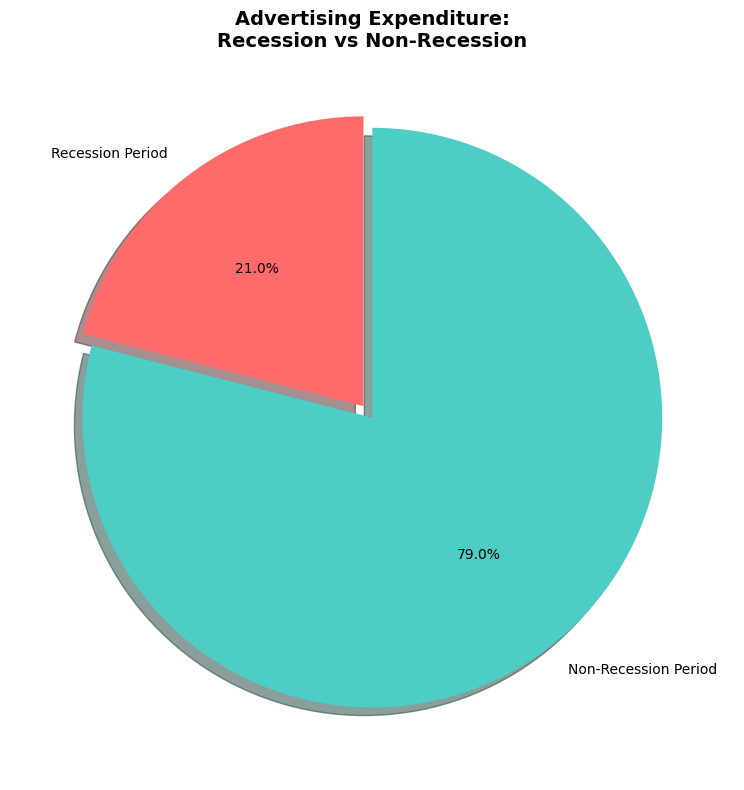

✅ Task 1.7 Done


In [8]:
# Total advertising during recession and non-recession
adv_rec     = df[df['Recession'] == 1]['Advertising_Expenditure'].sum()
adv_non_rec = df[df['Recession'] == 0]['Advertising_Expenditure'].sum()

labels  = ['Recession Period', 'Non-Recession Period']
sizes   = [adv_rec, adv_non_rec]
colors  = ['#FF6B6B', '#4ECDC4']
explode = (0.05, 0)

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=True
)
plt.title('Advertising Expenditure:\nRecession vs Non-Recession', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_7_pie_adv_recession.png', dpi=150)
plt.show()
print('✅ Task 1.7 Done')

### TASK 1.8: Pie Chart — Advertising Expenditure per Vehicle Type During Recession

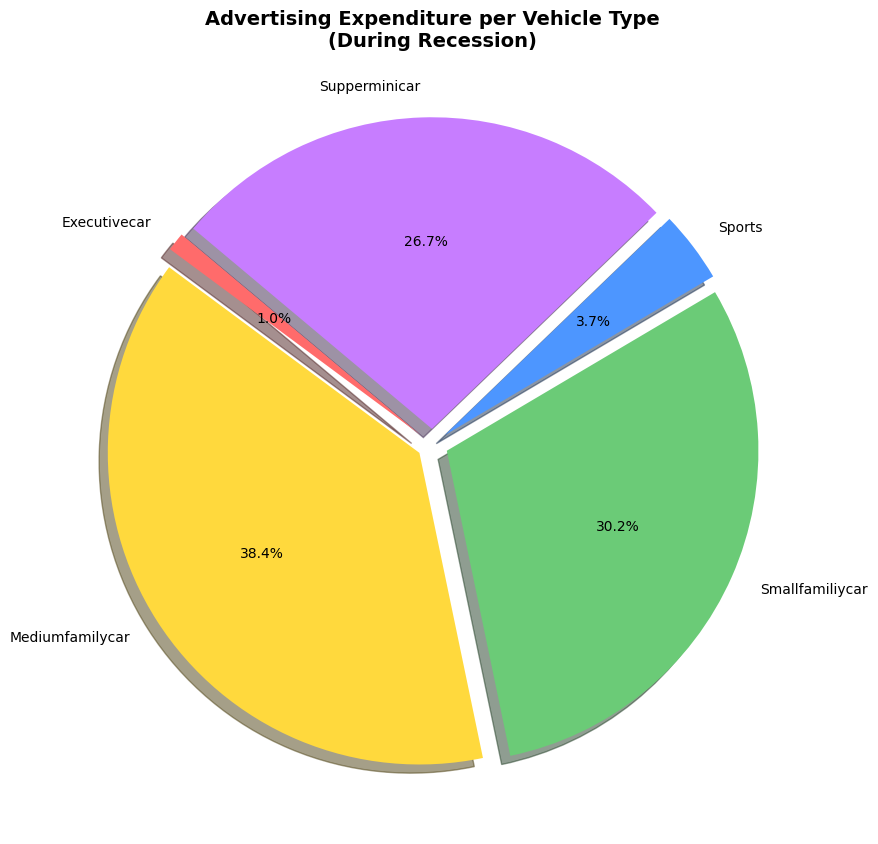

✅ Task 1.8 Done


In [9]:
df_rec = df[df['Recession'] == 1]
adv_by_vehicle = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

colors = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF', '#C77DFF']

plt.figure(figsize=(9, 9))
plt.pie(
    adv_by_vehicle,
    labels=adv_by_vehicle.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    shadow=True,
    explode=[0.05] * len(adv_by_vehicle)
)
plt.title('Advertising Expenditure per Vehicle Type\n(During Recession)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_8_pie_vehicle_adv.png', dpi=150)
plt.show()
print('✅ Task 1.8 Done')

### TASK 1.9: Line Plot — Unemployment Rate Effect on Vehicle Type & Sales During Recession

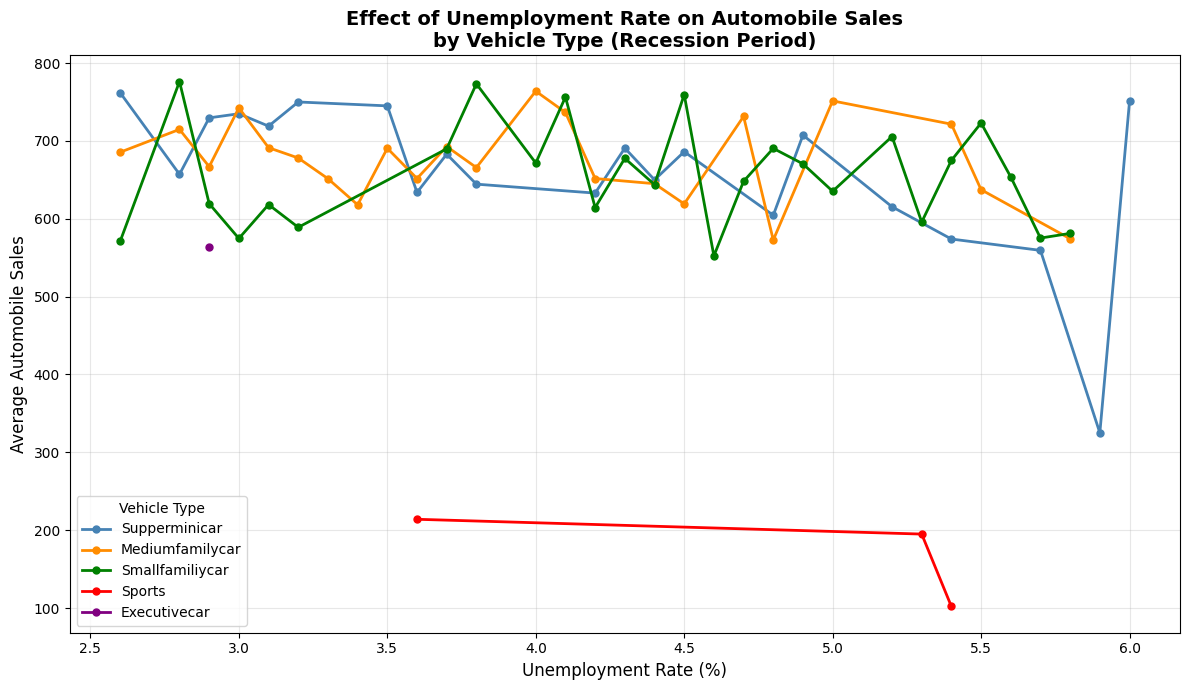

✅ Task 1.9 Done


In [11]:
df_rec = df[df['Recession'] == 1]

plt.figure(figsize=(12, 7))

vehicle_types = df_rec['Vehicle_Type'].unique()
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for i, vtype in enumerate(vehicle_types):
    vdf = df_rec[df_rec['Vehicle_Type'] == vtype]
    grouped = vdf.groupby('unemployment_rate')['Automobile_Sales'].mean()
    plt.plot(grouped.index, grouped.values,
             label=vtype,
             color=colors[i % len(colors)],
             linewidth=2,
             marker='o',
             markersize=5)

plt.title('Effect of Unemployment Rate on Automobile Sales\nby Vehicle Type (Recession Period)', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Average Automobile Sales', fontsize=12)
plt.legend(title='Vehicle Type', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_9_unemployment_sales.png', dpi=150)
plt.show()
print('✅ Task 1.9 Done')

---
## Summary

All Part 1 tasks completed successfully! ✅

**Key Insights:**
- Automobile sales dropped significantly during recession periods (1980, 1991, 2000–2001, 2007–2009, 2020)
- Higher advertising expenditure occurred during non-recession periods, correlating with higher sales
- Economy/smaller cars showed more resilience during recessions compared to executive/sports vehicles
- Higher unemployment rates are associated with lower automobile sales across all vehicle types
- Vehicle pricing and seasonality both influence sales patterns during recessions

---
**Part 2 (Dashboard)** → Run the file `automobile_dashboard.py` using: `python automobile_dashboard.py`